# Caller-Level Volume — Brizan Revisions Plus

Revised version of `04_caller_level_volume.ipynb`. **Same data, same paper-aligned
feature set, same caller roll-up** — only the *analyses* change.

**Feature set (unchanged from 04):** the paper-aligned volume block — Table 1's 14
features minus the 3 pitch features = 11 (`token_count`, loudness mean/std/range,
`Turn Gap`, `word_rate`, `syllable_rate`, `Pronouns per Second`, repetitions
current/previous, `Filler Words per Second`). Interactional features (latching,
overlap, questions, …) are a separate WIP and are **not** used here.

**Pseudoreplication fixed (unchanged from 04):** "speaker" = the **caller**, not the
`sw####A/B` conversation side. Each caller appears across ~9 calls; grouping by side
inflates n ~9×. We map side → `caller_no` via `tables/call_con_tab.csv`.

**What changed vs 04 (the Brizan revisions):**
1. **PC naming → 1-indexed** (`PC1, PC2, …`). The old `PC0` was a 0-indexing artifact.
2. **Dropped silhouette** (and the forced-k=2 split). Silhouette only scores how cleanly
   you can *force* a partition — uninformative for a continuum.
3. **Added distribution-shape battery:** skew, **excess kurtosis**, and **Hartigan's
   dip test** (formal unimodality test) on every retained PC. Kept a single GMM
   BIC(k=1 vs k=2) line as direct corroboration of the old "BIC picked k=2" worry.
4. **Added Horn's parallel analysis** to choose how many PCs to retain (PC1 explains
   only ~40%, so more than one component carries signal).
5. **Demographics reported as mean ± SD ± n over callers**, with significance tests
   (Welch t for gender; one-way ANOVA for region/generation/education) and
   **Benjamini-Hochberg FDR** across the family; plus a **group-overlay figure**
   (per-group density curves on the pooled histogram) for the paper.

In [1]:
import pandas as pd, numpy as np, string
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from scipy.stats import skew, kurtosis, gaussian_kde, ttest_ind, f_oneway, norm
from scipy.signal import find_peaks
from diptest import diptest
import seaborn as sns, matplotlib.pyplot as plt

# Benjamini-Hochberg FDR-adjusted p-values (avoids a statsmodels dependency)
def bh_fdr(pvals):
    p = np.asarray(pvals, dtype=float)
    m = len(p)
    order = np.argsort(p)
    adj = np.empty(m)
    prev = 1.0
    for rank in range(m - 1, -1, -1):
        idx = order[rank]
        prev = min(prev, p[idx] * m / (rank + 1))
        adj[idx] = prev
    return adj

## Step 1 — Load utterances & roll up conversation sides to callers (pseudoreplication fix)

In [2]:
df = pd.read_csv("../utterances_v2/paper_aligned_standardized_PCA.csv")

# --- speaker roll-up: collapse conversation SIDES to the actual CALLER ----------
# "sw####A/B" is a conversation SIDE, not a person. Each caller takes part in ~9
# calls, so grouping by side pseudo-replicates every speaker ~9x and inflates n in
# every downstream test (PCA point count, BIC, the gender Welch t).
# Map (conversation_no, side) -> caller_no with the corpus table and use the
# caller as the speaker, pooling all of their utterances across calls.
df["side"] = df["Utterance File Name"].str.extract(r"(sw\d+[AB])")
_cc = pd.read_csv("../tables/call_con_tab.csv", header=None,
                  names=["conv", "conv_side", "caller", "phone", "length",
                         "ivi", "remarks", "active"])
_cc["conv_side"] = _cc["conv_side"].str.strip().str.strip('"')
_side2caller = {f"sw{int(c):04d}{s}": int(k)
                for c, s, k in zip(_cc["conv"], _cc["conv_side"], _cc["caller"])}
df["speaker"] = df["side"].map(_side2caller)   # speaker == caller_no (the person)
_unmapped = int(df["speaker"].isna().sum())
df = df.dropna(subset=["speaker"]).copy()
df["speaker"] = df["speaker"].astype(int)
# -------------------------------------------------------------------------------

# paper-aligned volume features (Table 1 minus the 3 pitch features) — EXACTLY as 04
feature_cols = ["token_count", "loudness mean", "loudness std", "loudness range", "Turn Gap",
                "word_rate", "syllable_rate", "Pronouns per Second",
                "Repetitions In Current Utterance", "Repetitions In Previous Utterance",
                "Filler Words per Second"]
print(f"Utterances: {len(df)} | conversation sides: {df['side'].nunique()} "
      f"| distinct callers (speakers): {df['speaker'].nunique()} | unmapped utts dropped: {_unmapped}")

Utterances: 212210 | conversation sides: 3988 | distinct callers (speakers): 493 | unmapped utts dropped: 0


## Step 2 — Flag backchannels & aggregate each caller to a profile

(Backchannel allowlist unchanged from 04 — its validation/sensitivity is a separate task.)

In [3]:
BC = {"yeah", "yea", "yep", "yup", "yes", "ya", "yah", "uh-huh", "uhhuh", "huh-uh", "um-hum",
      "umhum", "mm-hmm", "mm-hm", "mmhm", "mhm", "m-hm", "mm", "mmm", "hm", "hmm", "hmmm",
      "hum", "huh", "uh", "um", "er", "erm", "ah", "oh", "ooh", "aw", "okay", "ok", "right",
      "sure", "wow", "gosh"}

def is_backchannel(t):
    toks = [w.strip(string.punctuation).lower() for w in str(t).split()]
    toks = [w for w in toks if w]
    return len(toks) > 0 and all(w in BC for w in toks)

df["is_bc"] = df["Transcript"].apply(is_backchannel)

# per-caller mean of features over SUBSTANTIVE utterances; plus backchannel rate over ALL utterances
sub = df[~df["is_bc"]]
spk = sub.groupby("speaker")[feature_cols].mean()
spk["n_sub"] = sub.groupby("speaker").size()
spk["bc_rate"] = df.groupby("speaker")["is_bc"].mean()
for dcol in ["Gender", "Region", "Generation", "Education", "Year Born"]:
    spk[dcol] = df.groupby("speaker")[dcol].first()

print(f"Substantive utterances/caller: median {int(spk['n_sub'].median())}, "
      f"min {spk['n_sub'].min()}, max {spk['n_sub'].max()}")
MIN = 20  # reliability floor (now nearly non-binding: caller pooling => median ~236 utts)
spk = spk[spk["n_sub"] >= MIN].copy()
print(f"Callers retained (>= {MIN} substantive utterances): {len(spk)}")

Substantive utterances/caller: median 236, min 11, max 1576
Callers retained (>= 20 substantive utterances): 487


## Step 3 — PCA across callers (standardized per-caller means), 1-indexed PCs

In [4]:
Xs = StandardScaler().fit_transform(spk[feature_cols].values)
pca = PCA(n_components=len(feature_cols))
scores = pca.fit_transform(Xs)
n_pc = scores.shape[1]
for j in range(n_pc):                       # store conventional 1-indexed columns PC1..PCk
    spk[f"PC{j+1}"] = scores[:, j]
evr = pca.explained_variance_ratio_
print(f"Callers: {len(spk)} | features: {len(feature_cols)}")
print(f"PC1 explained variance: {evr[0]*100:.2f}%  | cumulative to PC3: {evr[:3].sum()*100:.1f}%")
load = (pd.DataFrame({"Feature": feature_cols, "Loading": pca.components_[0]})
        .assign(a=lambda d: d.Loading.abs()).sort_values("a", ascending=False))
print("\nPC1 loadings:")
for _, r in load.iterrows():
    print(f"  {r.Loading:+.4f}  {r.Feature}")

Callers: 487 | features: 11
PC1 explained variance: 42.49%  | cumulative to PC3: 79.6%

PC1 loadings:
  +0.4155  token_count
  +0.4104  Repetitions In Current Utterance
  +0.3988  word_rate
  +0.3896  syllable_rate
  +0.3383  Repetitions In Previous Utterance
  +0.3036  Pronouns per Second
  +0.2025  Filler Words per Second
  +0.1817  loudness mean
  +0.1790  loudness range
  +0.1631  loudness std
  +0.0943  Turn Gap


## Step 4 — How many components to keep? Horn's parallel analysis

PC1 explains only ~40%, so structure lives beyond it. Parallel analysis keeps a
component only if its eigenvalue exceeds the 95th percentile of eigenvalues from
random data of the same shape — a principled replacement for eyeballing the scree.

Parallel analysis (data eigenvalue vs 95th-pct of random):
  PC 1: eig=4.683  rand95=1.310  -> KEEP
  PC 2: eig=2.832  rand95=1.229  -> KEEP
  PC 3: eig=1.256  rand95=1.163  -> KEEP
  PC 4: eig=0.769  rand95=1.112  -> drop
  PC 5: eig=0.731  rand95=1.069  -> drop
  PC 6: eig=0.346  rand95=1.028  -> drop
  PC 7: eig=0.268  rand95=0.988  -> drop
  PC 8: eig=0.072  rand95=0.948  -> drop
  PC 9: eig=0.042  rand95=0.909  -> drop
  PC10: eig=0.020  rand95=0.868  -> drop
  PC11: eig=0.004  rand95=0.820  -> drop

Components retained: K=3   (Kaiser eig>1 would keep 3)


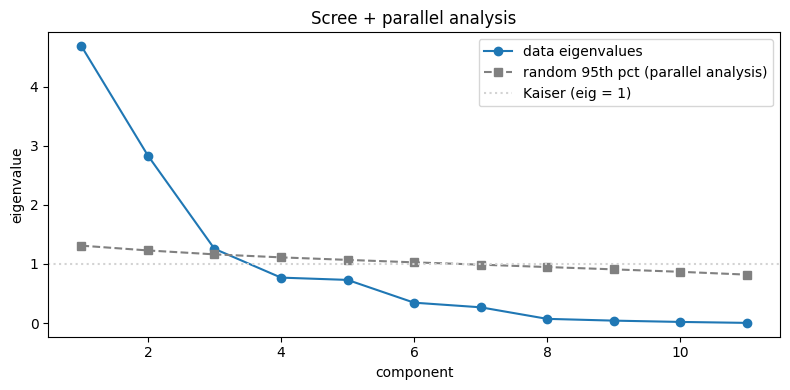

In [5]:
n, p = Xs.shape
eig_real = pca.explained_variance_                  # eigenvalues (standardized => correlation-matrix)
rng = np.random.default_rng(0)
N_ITER = 500
eig_rand = np.empty((N_ITER, p))
for i in range(N_ITER):
    Xr = StandardScaler().fit_transform(rng.standard_normal((n, p)))
    eig_rand[i] = PCA(n_components=p).fit(Xr).explained_variance_
thresh = np.percentile(eig_rand, 95, axis=0)
keep = eig_real > thresh
K = int(keep.sum())
print("Parallel analysis (data eigenvalue vs 95th-pct of random):")
for j in range(p):
    print(f"  PC{j+1:>2}: eig={eig_real[j]:.3f}  rand95={thresh[j]:.3f}  -> {'KEEP' if keep[j] else 'drop'}")
print(f"\nComponents retained: K={K}   (Kaiser eig>1 would keep {(eig_real>1).sum()})")

plt.figure(figsize=(8, 4))
plt.plot(range(1, p+1), eig_real, "o-", label="data eigenvalues")
plt.plot(range(1, p+1), thresh, "s--", color="gray", label="random 95th pct (parallel analysis)")
plt.axhline(1, color="lightgray", ls=":", label="Kaiser (eig = 1)")
plt.xlabel("component"); plt.ylabel("eigenvalue"); plt.title("Scree + parallel analysis")
plt.legend(); plt.tight_layout(); plt.show()

## Step 5 — Distribution shape of each retained PC (replaces silhouette)

For a continuum the question is "is each axis one smooth hump?", answered by skew +
**excess kurtosis** (0 = normal) and **Hartigan's dip test** (p > 0.05 = fail to
reject unimodality). Silhouette is gone — it only scores forced partitions. One GMM
BIC(k=1 vs k=2) line is kept as the direct answer to the old "BIC picked k=2".

In [6]:
print(f"{'PC':>4} {'skew':>7} {'exc.kurt':>9} {'dip':>7} {'dip p':>8}   KDE modes(.25/.4/.6)   verdict")
for j in range(K):
    v = scores[:, j]
    sk = skew(v); ku = kurtosis(v, fisher=True)          # excess kurtosis: 0 == normal
    dstat, dp = diptest(v)
    grid = np.linspace(v.min(), v.max(), 2000); modes = []
    for bw in (0.25, 0.40, 0.60):
        dens = gaussian_kde(v, bw_method=bw)(grid)
        modes.append(int(len(find_peaks(dens, prominence=dens.max()*0.05)[0])))
    verdict = "unimodal" if (dp > 0.05 and max(modes) == 1) else ("MULTIMODAL" if max(modes) > 1 else "unimodal*")
    print(f"PC{j+1:>2} {sk:>7.3f} {ku:>9.3f} {dstat:>7.4f} {dp:>8.3f}   {str(modes):>12}        {verdict}")

X1 = scores[:, [0]]
b1 = GaussianMixture(1, random_state=0).fit(X1).bic(X1)
b2 = GaussianMixture(2, random_state=0).fit(X1).bic(X1)
print(f"\nPC1 GMM BIC: k=1 {b1:.0f} | k=2 {b2:.0f} | dBIC(2-1) = {b2-b1:+.0f}"
      f"  ->  {'k=1 single component preferred' if b2 > b1 else 'k=2 preferred'}")
print("(dip p>0.05 AND single KDE mode AND BIC favouring k=1  =>  unimodal continuum)")

  PC    skew  exc.kurt     dip    dip p   KDE modes(.25/.4/.6)   verdict
PC 1   0.488     0.909  0.0119    0.955      [1, 1, 1]        unimodal


PC 2   1.198     2.691  0.0124    0.932      [1, 1, 1]        unimodal
PC 3   0.390     0.613  0.0102    0.992      [1, 1, 1]        unimodal

PC1 GMM BIC: k=1 2145 | k=2 2155 | dBIC(2-1) = +10  ->  k=1 single component preferred
(dip p>0.05 AND single KDE mode AND BIC favouring k=1  =>  unimodal continuum)


## Step 6 — Visual normalness: histograms with a fitted-normal overlay

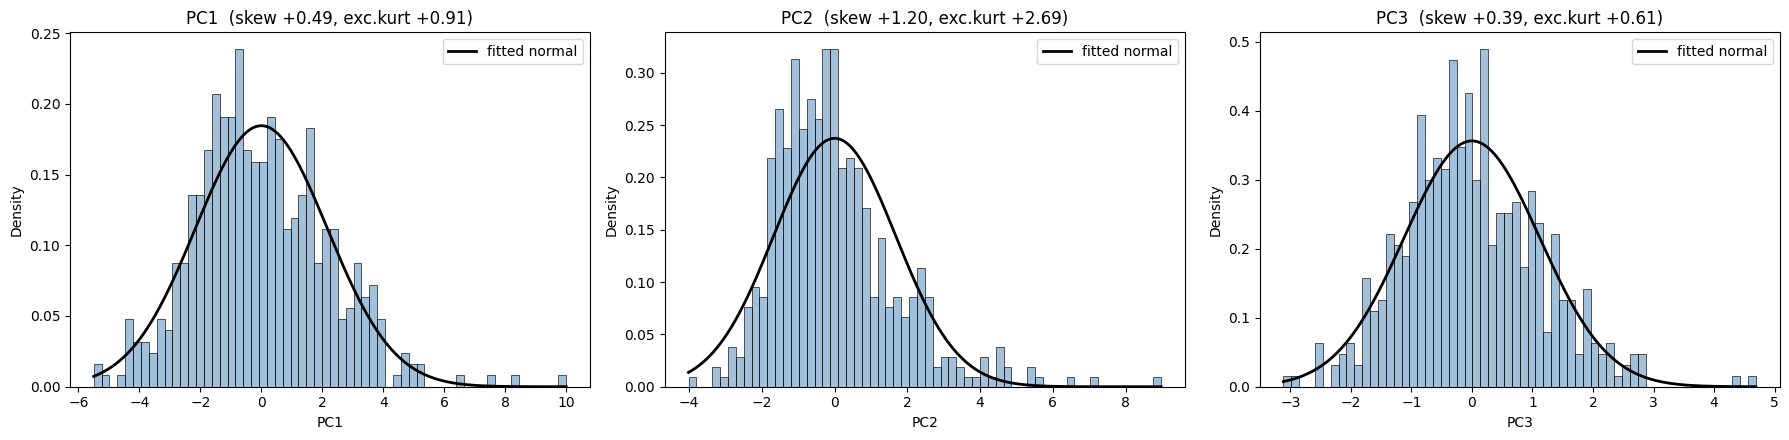

In [7]:
ncol = min(K, 3)
fig, axes = plt.subplots(1, ncol, figsize=(6*ncol, 4.5))
axes = np.atleast_1d(axes)
for j in range(ncol):
    v = scores[:, j]; ax = axes[j]
    sns.histplot(v, bins=60, stat="density", color="steelblue", alpha=0.5, ax=ax)
    xs = np.linspace(v.min(), v.max(), 400)
    ax.plot(xs, norm.pdf(xs, v.mean(), v.std()), "k-", lw=2, label="fitted normal")
    ax.set_title(f"PC{j+1}  (skew {skew(v):+.2f}, exc.kurt {kurtosis(v):+.2f})")
    ax.set_xlabel(f"PC{j+1}"); ax.legend()
plt.tight_layout(); plt.show()

## Step 7 — Sanity: PC1 is not just a backchannel/length artifact

In [8]:
pc1 = scores[:, 0]
print(f"PC1 correlation with backchannel rate: {np.corrcoef(pc1, spk['bc_rate'])[0,1]:+.3f}")
print(f"PC1 correlation with #utterances:      {np.corrcoef(pc1, spk['n_sub'])[0,1]:+.3f}")
print("(near zero => PC1 reflects volume style, not how many backchannels / utterances a caller has)")

PC1 correlation with backchannel rate: -0.079
PC1 correlation with #utterances:      +0.026
(near zero => PC1 reflects volume style, not how many backchannels / utterances a caller has)


## Step 8 — Demographics in PC space: mean ± SD ± n + significance (FDR-corrected)

Unit = **caller** (independent observations), so these tests are legitimate. Welch t
for gender (2 groups), one-way ANOVA for region/generation/education; Benjamini-
Hochberg FDR across the whole family of demographic×PC tests. Tiny groups (n<5) are
dropped from the test.

In [9]:
DEMOS = ["Gender", "Region", "Generation", "Education"]
rows = []
for dcol in DEMOS:
    for j in range(K):
        pcname = f"PC{j+1}"
        g = spk.groupby(dcol)[pcname].agg(["mean", "std", "count"])
        g = g[g["count"] >= 5].sort_values("mean")
        if len(g) < 2:
            continue
        if dcol == "Gender":
            grp = g.index.tolist()[:2]
            a = spk.loc[spk[dcol]==grp[0], pcname]; b = spk.loc[spk[dcol]==grp[1], pcname]
            stat, pval = ttest_ind(a, b, equal_var=False)
            dd = (a.mean()-b.mean()) / np.sqrt((a.var(ddof=1)+b.var(ddof=1))/2)
            rows.append((dcol, pcname, "Welch t", stat, pval, f"d={dd:+.2f}"))
        else:
            groups = [spk.loc[spk[dcol]==ix, pcname].values for ix in g.index]
            stat, pval = f_oneway(*groups)
            rows.append((dcol, pcname, "ANOVA F", stat, pval, f"{len(groups)} grps"))
        if j == 0:
            print(f"=== {dcol} on PC1 (mean +/- SD, n) ===")
            print(g.round(3).to_string()); print()

res = pd.DataFrame(rows, columns=["demographic", "PC", "test", "stat", "p_raw", "extra"])
res["p_fdr"] = bh_fdr(res["p_raw"].values)
res["sig"] = np.where(res["p_fdr"] < 0.05, "***", "")
print("Significance across all demographic x PC tests (BH-FDR):")
print(res.assign(stat=res["stat"].round(2),
                 p_raw=res["p_raw"].map(lambda x: f"{x:.1e}"),
                 p_fdr=res["p_fdr"].map(lambda x: f"{x:.1e}")).to_string(index=False))

=== Gender on PC1 (mean +/- SD, n) ===
         mean    std  count
Gender                     
female -0.522  1.978    232
male    0.475  2.219    255

=== Region on PC1 (mean +/- SD, n) ===
                mean    std  count
Region                            
mixed         -0.309  1.358     26
western       -0.307  2.198     76
south_midland -0.255  2.038    147
northern       0.062  2.216     69
southern       0.310  2.471     52
north_midland  0.368  2.250     69
new_england    0.453  2.492     18
nyc            0.500  2.040     30

=== Generation on PC1 (mean +/- SD, n) ===
               mean    std  count
Generation                       
Generation_X -0.202  2.184     83
Silent       -0.173  2.034    116
Baby_Boomer   0.142  2.199    286

=== Education on PC1 (mean +/- SD, n) ===
            mean    std  count
Education                     
1         -0.377  1.797     37
2         -0.202  2.104    278
3          0.364  2.212    162
0          1.767  4.090      6

Significance ac

## Step 8b — Education robustness (drop the unknown bucket)

Education code `0` is a tiny (n=6), wildly-variable group (mean +1.77 ± 4.09) — almost
certainly "unknown/unreported", not a real level. Re-run the Education ANOVA without it
to check the effect isn't an artifact of that bucket.

In [10]:
EDU_DROP = {0}          # unknown/unreported (code 9, n=4, is already excluded by n>=5)
sub_edu = spk[~spk["Education"].isin(EDU_DROP)]
print(f"Education levels used (n>=5, excluding unknown {sorted(EDU_DROP)}):\n")
for j in range(K):
    pcname = f"PC{j+1}"
    g = sub_edu.groupby("Education")[pcname].agg(["mean", "std", "count"])
    g = g[g["count"] >= 5]
    groups = [sub_edu.loc[sub_edu["Education"]==e, pcname].values for e in g.index]
    F, pp = f_oneway(*groups)
    with0 = res[(res["demographic"]=="Education") & (res["PC"]==pcname)]["p_raw"]
    p_with = with0.iloc[0] if len(with0) else float("nan")
    if j == 0:
        print(g.round(3).to_string()); print()
    print(f"  {pcname}: ANOVA F={F:.2f}  p={pp:.3f}   (with code 0: p={p_with:.3f})"
          f"   -> {'survives' if pp < 0.05 else 'not sig'}")
print("\n(PC1 shows a monotonic 1<2<3 level trend => graded effect, not an n=6 outlier.)")

Education levels used (n>=5, excluding unknown [0]):

            mean    std  count
Education                     
1         -0.377  1.797     37
2         -0.202  2.104    278
3          0.364  2.212    162

  PC1: ANOVA F=4.20  p=0.016   (with code 0: p=0.007)   -> survives
  PC2: ANOVA F=0.12  p=0.889   (with code 0: p=0.145)   -> not sig
  PC3: ANOVA F=4.63  p=0.010   (with code 0: p=0.025)   -> survives

(PC1 shows a monotonic 1<2<3 level trend => graded effect, not an n=6 outlier.)


## Step 9 — Group differences overlaid on the distribution (paper figure)

Per-group density curves drawn over the pooled PC1 histogram, with each group's mean
marked. This is the figure for the write-up: it shows *where* a group sits on the
continuum and how much the groups overlap (i.e. how real the difference is).

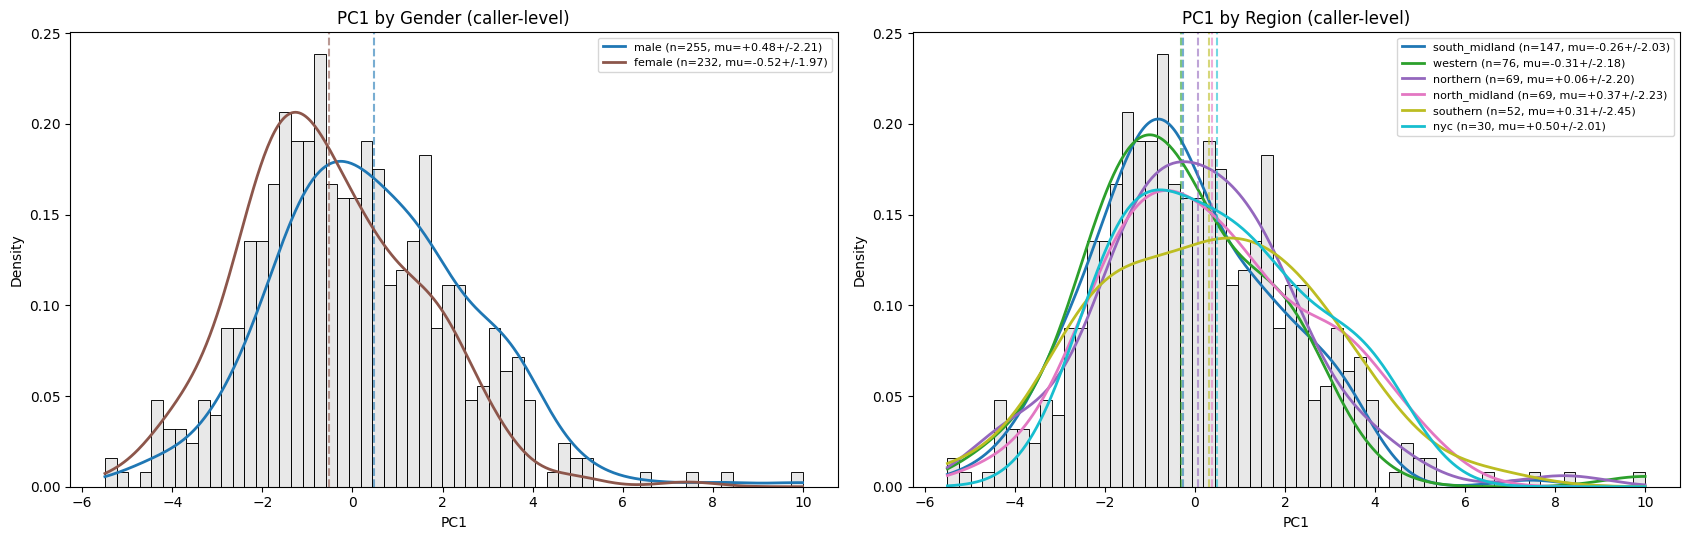

In [11]:
def overlay(ax, dcol, pcname="PC1", top=None):
    v = spk[pcname].values
    sns.histplot(v, bins=60, stat="density", color="lightgray", alpha=0.5, ax=ax)
    vc = spk[dcol].value_counts()
    cats = list(vc.index if top is None else vc.head(top).index)
    xs = np.linspace(v.min(), v.max(), 400)
    cmap = plt.cm.tab10(np.linspace(0, 1, max(len(cats), 3)))
    for c, col in zip(cats, cmap):
        vg = spk.loc[spk[dcol]==c, pcname].values
        if len(vg) < 5:
            continue
        ax.plot(xs, gaussian_kde(vg)(xs), color=col, lw=2,
                label=f"{c} (n={len(vg)}, mu={vg.mean():+.2f}+/-{vg.std():.2f})")
        ax.axvline(vg.mean(), color=col, ls="--", alpha=0.6)
    ax.set_title(f"{pcname} by {dcol} (caller-level)"); ax.set_xlabel(pcname)
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(17, 5.5))
overlay(axes[0], "Gender")
overlay(axes[1], "Region", top=6)
plt.tight_layout(); plt.show()

## Step 10 — Recorded summary

In [12]:
print("="*72)
print("CALLER-LEVEL VOLUME (BRIZAN REVISIONS) — KEY RESULTS")
print("="*72)
v1 = scores[:, 0]; dp1 = diptest(v1)[1]
print(f"Unit: caller (n={len(spk)})  |  {len(feature_cols)} paper-aligned volume features"
      f"  |  PCs retained (parallel analysis): K={K}")
print(f"PC1 variance {evr[0]*100:.1f}%  | skew {skew(v1):+.2f}  excess-kurtosis {kurtosis(v1):+.2f}"
      f"  | Hartigan dip p={dp1:.3f} -> {'unimodal' if dp1>0.05 else 'reject unimodality'}")
sigs = res[res["p_fdr"] < 0.05]
print(f"Significant demographic effects (FDR<0.05): {len(sigs)} of {len(res)} tests")
for _, r in sigs.iterrows():
    print(f"   {r['demographic']:11s} on {r['PC']}: {r['test']} p_fdr={r['p_fdr']:.1e}  {r['extra']}")
ns = res[res["p_fdr"] >= 0.05]
print(f"Not significant: " + ", ".join(f"{r['demographic']}/{r['PC']}" for _, r in ns.iterrows()))

CALLER-LEVEL VOLUME (BRIZAN REVISIONS) — KEY RESULTS
Unit: caller (n=487)  |  11 paper-aligned volume features  |  PCs retained (parallel analysis): K=3
PC1 variance 42.5%  | skew +0.49  excess-kurtosis +0.91  | Hartigan dip p=0.955 -> unimodal
Significant demographic effects (FDR<0.05): 4 of 12 tests
   Gender      on PC1: Welch t p_fdr=2.8e-06  d=-0.47
   Gender      on PC2: Welch t p_fdr=1.2e-02  d=-0.27
   Gender      on PC3: Welch t p_fdr=1.3e-05  d=-0.43
   Education   on PC1: ANOVA F p_fdr=2.1e-02  4 grps
Not significant: Region/PC1, Region/PC2, Region/PC3, Generation/PC1, Generation/PC2, Generation/PC3, Education/PC2, Education/PC3


## Conclusion (recorded)

**Shape — a unimodal, multi-dimensional continuum.** Parallel analysis retains **K=3**
components (PC1 42.5%, cumulative-to-PC3 79.6%). All three are unimodal: Hartigan's dip
p = **0.96 / 0.93 / 0.99** (nowhere near rejecting unimodality), a single KDE mode at
every bandwidth, and GMM BIC prefers k=1 (ΔBIC(2−1) = **+10**) — the old "BIC picked
k=2" was a side-level **pseudoreplication** artifact, gone at caller level. Caveat:
*unimodal* ≠ *normal* — PC1 is mildly right-skewed (skew +0.49, excess kurtosis +0.91)
and PC2 clearly so (+1.20 / +2.69); the continuum claim rests on **unimodality**, not
normality, and the airtight version still needs the dip/BLRT/taxometric battery. PC1 is
genuine volume style, not an artifact (r with backchannel rate −0.08, with utterance
count +0.03).

**Demographics (caller-level, FDR-corrected) — 4 of 12 tests survive:**
- **Gender — robust on all three axes:** PC1 d=−0.47 (p_fdr 2.8e-6), PC2 d=−0.27
  (1.2e-2), PC3 d=−0.43 (1.3e-5). Women lower on the volume axes, men higher.
- **Education — robust on PC1** (p_fdr 0.021), surviving removal of the n=6 unknown
  bucket (raw p 0.007 → 0.016) with a monotonic 1<2<3 trend — a graded effect, not an
  outlier. **PC3 is borderline** (p_fdr 0.060 with the bucket; raw p 0.010 without it):
  a candidate education effect worth confirming, not dismissing. PC2 null.
- **Region — not significant on any axis** (ANOVA p_fdr 0.36–0.73). The earlier "NYC is
  most distinctive" was side-level pseudoreplication; it does **not** hold per-person.
- **Generation — not significant.**

Differences are shifts *along* the continuum (Step 9 overlay): groups overlap heavily,
so even the robust gender effect is a modest mean shift, not two populations.

Deferred (not in this notebook): backchannel-definition validation vs NXT gold; and
re-including within-speaker-normalized pitch dynamics.